# Cost Prediction: Data Preparation
This notebook prepares the dataset to predict cost given knob configuration and workload internal metrics.

- Source records: `surrogate/combined_runhistory.json` (`records` contain knob config and `cost`).
- Internal metrics: `internal_metrics/<bench>/<bench>_<idx>_internal_metrics.json` selected by parsing `__source` in each record.
- Output: `x_train, y_train, x_test, y_test` ready for model training.

In [1]:
import os
import re
import json
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

cwd = Path.cwd()
# Try multiple locations to find combined_runhistory.json
surrogate_dir_candidates = [
    cwd,                           # Current directory
    cwd / 'surrogate',             # Subdirectory named surrogate
    Path(__file__).parent if '__file__' in globals() else cwd,  # Notebook's own directory
    cwd.parent / 'surrogate' if cwd.name == 'surrogate' else cwd / 'surrogate',  # Parent's surrogate or current surrogate
]

combo_path = None
for cand in surrogate_dir_candidates:
    cp = cand / 'combined_runhistory.json'
    if cp.exists():
        combo_path = cp
        break

# If still not found, raise a clear error
if combo_path is None:
    raise FileNotFoundError(
        "Could not find 'combined_runhistory.json'. Please ensure it exists in:\n"
        f"  - {cwd / 'combined_runhistory.json'}\n"
        f"  - {cwd / 'surrogate' / 'combined_runhistory.json'}\n"
        "Or update the search paths in this cell."
    )

project_root = combo_path.parent.parent if combo_path.name == 'combined_runhistory.json' else cwd
internal_metrics_dir = project_root / 'internal_metrics'
print('Using combined_runhistory.json at:', combo_path)
print('Using internal metrics dir:', internal_metrics_dir)

Using combined_runhistory.json at: /home/E2ETune-AI4DB/surrogate/combined_runhistory.json
Using internal metrics dir: /home/E2ETune-AI4DB/internal_metrics


In [2]:
bench_patterns = {
    'job': re.compile(r"job_(\d+)_hebo_output"),
    'tpch': re.compile(r"tpch_(\d+)_hebo_output"),
    'tpcds': re.compile(r"tpcds_(\d+)_hebo_output"),
    'ssb': re.compile(r"ssb_(\d+)_hebo_output"),
    # 'tpcc': re.compile(r"sample_tpcc_config(\d+)_hebo_output"),
    # 'smallbank': re.compile(r"sample_smallbank_config(\d+)_hebo_output"),
    # 'twitter': re.compile(r"sample_twitter_config(\d+)_hebo_output"),
}

def parse_bench_and_idx(source_path: str):
    p = Path(source_path)
    parts = [str(x) for x in p.parts]
    bench = None
    for b in ['job','tpch','tpcds','ssb']:
        if b in parts:
            bench = b
            break
    if bench is None:
        return None

    match = bench_patterns[bench].search(source_path)
    if not match:
        return None
    idx = int(match.group(1))
    return bench, idx

def metrics_path_for(bench: str, idx: int) -> Path:
    # Standard path format
    standard_path = internal_metrics_dir / bench / f"{bench}_{idx}_internal_metrics.json"
    if standard_path.exists():
        return standard_path
    
    # # Alternative path formats for different benchmarks
    # if bench == 'tpcc':
    #     alt_path = internal_metrics_dir / bench / f"sample_tpcc_config{idx}.xml_internal_metrics.json"
    #     if alt_path.exists():
    #         return alt_path
    # elif bench == 'smallbank':
    #     alt_path = internal_metrics_dir / bench / f"sample_smallbank_config{idx}.xml_internal_metrics.json"
    #     if alt_path.exists():
    #         return alt_path
    # elif bench == 'twitter':
    #     alt_path = internal_metrics_dir / bench / f"sample_twitter_config{idx}.xml_internal_metrics.json"
    #     if alt_path.exists():
    #         return alt_path
    
    return standard_path

_metrics_cache = {}

def load_internal_metrics(bench: str, idx: int) -> dict:
    key = (bench, idx)
    if key in _metrics_cache:
        return _metrics_cache[key]
    mp = metrics_path_for(bench, idx)
    if not mp.exists():
        return {}
    try:
        with open(mp, 'r') as f:
            raw = json.load(f)
        flat = pd.json_normalize(raw, sep='__')
        metrics = flat.to_dict(orient='records')[0] if len(flat) else {}
    except Exception:
        metrics = {}
    _metrics_cache[key] = metrics
    return metrics


In [3]:
# Workload features and query plan feature loaders
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

workload_features_dir = project_root / 'workload_features'
query_plans_dir = project_root / 'query_plans'

_workload_cache = {}
_plans_cache = {}

# Path helpers
def workload_features_path_for(bench: str, idx: int) -> Path:
    return workload_features_dir / bench / f"{bench}_{idx}_features.json"


def query_plans_path_for(bench: str, idx: int) -> Path:
    return query_plans_dir / bench / f"{bench}_{idx}_plans.json"


# Loaders
def load_workload_features(bench: str, idx: int) -> dict:
    """Load simple workload-level features like size, ratios, avg lengths.
    Returns {} if missing or on error.
    """
    key = (bench, idx)
    if key in _workload_cache:
        return _workload_cache[key]
    p = workload_features_path_for(bench, idx)
    if not p.exists():
        _workload_cache[key] = {}
        return {}
    try:
        with open(p, 'r') as f:
            data = json.load(f)
        # Ensure numeric values and safe defaults
        result = {}
        for k, v in data.items():
            try:
                result[k] = float(v)
            except Exception:
                # Keep non-numeric as-is if needed
                result[k] = v
    except Exception:
        result = {}
    _workload_cache[key] = result
    return result


# Plan vectorization
OP_RE = re.compile(r'([A-Za-z ]+)\(cost=([0-9.]+)\)')


def vectorize_plans(plan_strings: list[str]) -> dict:
    """Parse plan strings into engineered features.
    Produces operator counts/ratios, top-level cost stats, depth proxies, and binary flags.
    """
    op_counts: dict[str, int] = {}
    top_costs: list[float] = []
    depths: list[int] = []

    for s in plan_strings or []:
        ops = OP_RE.findall(s)
        if not ops:
            continue
        # Top-level operator's cost
        try:
            top_costs.append(float(ops[0][1]))
        except Exception:
            pass
        # Simple proxy for depth: parentheses count
        depths.append(s.count('('))
        for name, cost in ops:
            key = name.strip().lower().replace(' ', '_')
            op_counts[key] = op_counts.get(key, 0) + 1

    total_ops = sum(op_counts.values()) or 1
    ratios = {f'plan__ratio__{k}': (v / total_ops) for k, v in op_counts.items()}

    agg = {
        'plan__cost_mean': float(np.mean(top_costs)) if top_costs else 0.0,
        'plan__cost_std': float(np.std(top_costs)) if top_costs else 0.0,
        'plan__cost_min': float(np.min(top_costs)) if top_costs else 0.0,
        'plan__cost_max': float(np.max(top_costs)) if top_costs else 0.0,
        'plan__depth_mean': float(np.mean(depths)) if depths else 0.0,
        'plan__depth_max': float(np.max(depths)) if depths else 0.0,
        'plan__has_index_scan': int('index_scan' in op_counts),
        'plan__has_seq_scan': int('seq_scan' in op_counts),
        'plan__has_sort': int('sort' in op_counts),
        'plan__has_aggregate': int('aggregate' in op_counts),
        'plan__has_hash_join': int('hash_join' in op_counts),
        'plan__has_nested_loop': int('nested_loop' in op_counts),
        'plan__has_merge_join': int('merge_join' in op_counts),
        'plan__has_gather': int('gather' in op_counts),
        'plan__has_gather_merge': int('gather_merge' in op_counts),
        'plan__has_bitmap_scan': int('bitmap_heap_scan' in op_counts or 'bitmap_index_scan' in op_counts),
    }
    counts = {f'plan__count__{k}': v for k, v in op_counts.items()}
    return {**counts, **ratios, **agg}


def load_query_plan_features(bench: str, idx: int) -> dict:
    """Load and parse query plan strings into engineered features.
    Returns {} if missing or on error.
    """
    key = (bench, idx)
    if key in _plans_cache:
        return _plans_cache[key]
    p = query_plans_path_for(bench, idx)
    if not p.exists():
        _plans_cache[key] = {}
        return {}
    try:
        with open(p, 'r') as f:
            data = json.load(f)
        plans = data.get('query_plans', [])
        feats = vectorize_plans(plans)
    except Exception:
        feats = {}
    _plans_cache[key] = feats
    return feats

In [4]:
def select_config_dict(rec: dict):
    if 'config' in rec and isinstance(rec['config'], dict):
        return rec['config']
    else:
        return None


def select_cost_value(rec: dict):
    if 'cost' in rec:
        v = rec.get('cost')
        if isinstance(v, (int, float)) or (isinstance(v, list) and len(v) == 1 and isinstance(v[0], (int, float))):
            cost = float(v[0]) if isinstance(v, list) else float(v)
            return abs(cost)  # Make all costs positive
    else:
        return None

with open(combo_path, 'r') as f:
    combo = json.load(f)
records = combo.get('records', [])
print('Loaded records:', len(records))

feature_rows = []
targets = []

skipped_no_cost = 0
skipped_no_config = 0
skipped_no_metrics = 0

for rec in records:
    src = rec.get('__source', '')
    parsed = parse_bench_and_idx(src)
    if not parsed:
        skipped_no_metrics += 1
        continue
    bench, idx = parsed
    metrics = load_internal_metrics(bench, idx)
    workload = load_workload_features(bench, idx)
    plan_feats = load_query_plan_features(bench, idx)
    config = select_config_dict(rec)
    cost = select_cost_value(rec)

    if cost is None:
        skipped_no_cost += 1
        continue
    if config is None:
        skipped_no_config += 1
        continue

    config_flat = pd.json_normalize(config, sep='__').to_dict(orient='records')[0] if isinstance(config, dict) else {}
    row = {}
    row.update({f'cfg__{k}': v for k, v in config_flat.items()})
    row.update({f'metrics__{k}': v for k, v in metrics.items()})
    row.update({f'workload__{k}': v for k, v in (workload or {}).items()})
    # plan feature keys already prefixed as plan__*
    row.update(plan_feats or {})
    row['bench'] = bench
    row['workload_idx'] = idx

    feature_rows.append(row)
    targets.append(cost)

print('Rows collected:', len(feature_rows))
print('Skipped (no cost):', skipped_no_cost)
print('Skipped (no config):', skipped_no_config)
print('Skipped (no metrics parse):', skipped_no_metrics)

df = pd.DataFrame(feature_rows)
print('Raw feature shape:', df.shape)
try:
    print('Example columns (first 10):', list(df.columns)[:10])
except Exception:
    pass

df.head(3)

Loaded records: 9191
Rows collected: 5252
Skipped (no cost): 0
Skipped (no config): 0
Skipped (no metrics parse): 3939
Raw feature shape: (5252, 84)
Example columns (first 10): ['cfg__shared_buffers', 'cfg__work_mem', 'cfg__maintenance_work_mem', 'cfg__effective_cache_size', 'cfg__max_connections', 'cfg__wal_buffers', 'cfg__checkpoint_completion_target', 'cfg__checkpoint_timeout', 'cfg__effective_io_concurrency', 'cfg__join_collapse_limit']


,cfg__shared_buffers,cfg__work_mem,cfg__maintenance_work_mem,cfg__effective_cache_size,cfg__max_connections,cfg__wal_buffers,cfg__checkpoint_completion_target,cfg__checkpoint_timeout,cfg__effective_io_concurrency,cfg__join_collapse_limit,...,plan__has_gather_merge,plan__has_bitmap_scan,bench,workload_idx,plan__count__index_only_scan,plan__ratio__index_only_scan,plan__count__materialize,plan__ratio__materialize,plan__count__limit,plan__ratio__limit
0,131072.0,65536.0,262144.0,3145728.0,200.0,2048.0,0.900000,900.0,100.0,8.0,...,1,1,job,0,NaN,NaN,NaN,NaN,NaN,NaN
1,568513.0,55023.0,1205460.0,363298.0,116.0,529.0,0.830175,1346.0,50.0,17.0,...,1,1,job,0,NaN,NaN,NaN,NaN,NaN,NaN
2,1393434.0,227880.0,930768.0,2785250.0,455.0,5912.0,0.624197,525.0,235.0,9.0,...,1,1,job,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import pandas as pd
import numpy as np

# Calculate average cost per benchmark

# Create a DataFrame with cost and benchmark info
cost_by_bench = pd.DataFrame({
    'cost': targets,
    'benchmark': [row['bench'] for row in feature_rows]
})

# Calculate average cost per benchmark
avg_cost_per_bench = cost_by_bench.groupby('benchmark')['cost'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
avg_cost_per_bench.columns = ['count', 'avg_cost', 'std_cost', 'min_cost', 'max_cost']

print("Average cost per benchmark:")
print("=" * 50)
print(avg_cost_per_bench.sort_values('avg_cost', ascending=False))

# Overall statistics
print(f"\nOverall statistics:")
print(f"Total records: {len(targets)}")
print(f"Overall average cost: {np.mean(targets):.4f}")
print(f"Overall std cost: {np.std(targets):.4f}")

Average cost per benchmark:
           count  avg_cost  std_cost  min_cost  max_cost
benchmark                                               
job         1313   10.8674   28.4389    0.1276  135.3516
tpcds       1313    6.7347    4.5423    1.1575   24.8840
ssb         1313    2.6709    1.1127    0.5082    4.9899
tpch        1313    1.9487    1.0542    0.2936    4.4909

Overall statistics:
Total records: 5252
Overall average cost: 5.5554
Overall std cost: 14.8497


In [6]:
# # Per-workload target normalization
# normalization = 'minmax'  # options: 'zscore', 'minmax'

# # Build group key (bench + workload_idx)
grp = df['bench'].astype(str) + '_' + df['workload_idx'].astype(str)
# cost_series = pd.Series(targets, name='cost')
# cost_series_log = np.log1p(pd.Series(targets, name='cost'))
# def _zscore(vals: pd.Series):
#     s = float(vals.std(ddof=0))
#     if s == 0 or np.isnan(s):
#         return vals * 0.0
#     m = float(vals.mean())
#     return (vals - m) / s

# def _minmax(vals: pd.Series):
#     mn = float(vals.min()); mx = float(vals.max())
#     if mx == mn:
#         return vals * 0.0
#     return (vals - mn) / (mx - mn)

# if normalization == 'zscore':
#     norm_series = cost_series.groupby(grp).transform(_zscore)
# else:
#     norm_series = cost_series.groupby(grp).transform(_minmax)

# y_norm = norm_series.values.astype(float)
# print(f"Per-workload normalization: {normalization}")
# print('y_norm stats -> mean:', float(np.nanmean(y_norm)), 'std:', float(np.nanstd(y_norm)))


cost_series_log = np.log1p(pd.Series(targets, name='cost'))

# Now apply MinMax on the LOG values
def _minmax(vals: pd.Series):
    mn = float(vals.min())
    mx = float(vals.max())
    if mx == mn:
        return vals * 0.0
    return (vals - mn) / (mx - mn)

# Use the log series for grouping and transformation
norm_series = cost_series_log.groupby(grp).transform(_minmax)

y_norm = norm_series.values.astype(float)
print(f"Applied Log1p -> MinMax Normalization")

Applied Log1p -> MinMax Normalization


In [7]:
# Format features: one-hot categorical,split train/test
# Identify feature columns and target
y_raw = np.array(targets)
try:
    y = y_norm
except NameError:
    y = y_raw

X = df.copy()

# Drop grouping-only columns to prevent leakage
for col in ['bench', 'workload_idx']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Normalize knob columns using ranges from knob_config/knob_config.json
import json

# Load knob ranges (use project_root if available)
try:
    with open(project_root / 'knob_config/knob_config.json', 'r') as f:
        knob_ranges = json.load(f)
except Exception:
    with open('knob_config/knob_config.json', 'r') as f:
        knob_ranges = json.load(f)

def _normalize_knob(orig_key, val):
    rng = knob_ranges.get(orig_key)
    if rng is None:
        # If knob not in ranges, pass through numeric value
        return float(val) if pd.notnull(val) else 0.0
    mn = float(rng.get('min', 0.0))
    mx = float(rng.get('max', mn))
    if not pd.notnull(val):
        return 0.0
    v = float(val)
    return 0.0 if mx == mn else (v - mn) / (mx - mn)

# Apply normalization to all cfg__* columns
cfg_cols = [c for c in X.columns if c.startswith('cfg__')]
for c in cfg_cols:
    orig = c.replace('cfg__', '')
    X[c] = pd.to_numeric(X[c], errors='coerce')
    X[c] = X[c].apply(lambda v: _normalize_knob(orig, v))

# Convert categorical columns (object dtype) to dummies
categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
X = pd.get_dummies(X, columns=categorical_cols, dummy_na=True)

# Optional: ensure numeric type
for col in X.columns:
    # Convert booleans to ints
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)
    # Convert any non-numeric to string dummies already; remaining should be numeric
    if not np.issubdtype(X[col].dtype, np.number):
        try:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
        except Exception:
            pass

print('Final feature shape:', X.shape)

Final feature shape: (5252, 82)


In [8]:
# Group-aware train/test split (hold out entire workloads)
from sklearn.model_selection import GroupShuffleSplit
groups = df['bench'].astype(str) + '_' + df['workload_idx'].astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# from sklearn.model_selection import train_test_split
# train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)

# Train-only min–max normalization for metrics/workload/plan numeric columns
metrics_cols = [c for c in X.columns if c.startswith('metrics__')]
workload_cols = [c for c in X.columns if c.startswith('workload__')]
# Normalize plan numeric features but keep binary flags (plan__has_*) as 0/1
plan_norm_cols = [c for c in X.columns if c.startswith('plan__') and not c.startswith('plan__has_')]

norm_cols = metrics_cols + workload_cols + plan_norm_cols
if len(norm_cols) > 0:
    # Ensure numeric
    for c in norm_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    train_subset = X.iloc[train_idx][norm_cols]
    mn = train_subset.min()
    mx = train_subset.max()
    rng = mx - mn
    rng = rng.replace(0, np.nan)
    X.loc[:, norm_cols] = (X[norm_cols] - mn) / rng
    X.loc[:, norm_cols] = X[norm_cols].fillna(0.0).clip(0.0, 1.0)
    print('Applied train-only min–max normalization to metrics__/workload__/plan__* (excluding flags).')

x_train, x_test = X.values[train_idx], X.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Group-aware split:', x_train.shape, x_test.shape)

Applied train-only min–max normalization to metrics__/workload__/plan__* (excluding flags).
Group-aware split: (4141, 82) (1111, 82)


In [9]:
import json
import numpy as np
from pathlib import Path

# Save feature scaler statistics for inference

# Ensure output directory exists
try:
    out_dir = project_root / 'surrogate'
except NameError:
    out_dir = Path('surrogate')
out_dir.mkdir(parents=True, exist_ok=True)

# Prepare scaler statistics from training data
scaler_stats = {}

# Save min/max statistics for normalization columns used during training
if 'mn' in globals() and 'mx' in globals() and len(norm_cols) > 0:
    # Convert pandas Series to clean dictionaries with finite values only
    feature_min = {}
    feature_max = {}
    feature_range = {}
    
    for col in norm_cols:
        if col in mn.index and col in mx.index:
            min_val = float(mn[col])
            max_val = float(mx[col])
            
            # Handle NaN/inf values by setting them to 0
            if not np.isfinite(min_val):
                min_val = 0.0
            if not np.isfinite(max_val):
                max_val = min_val  # If max is also invalid, set equal to min
            
            feature_min[col] = min_val
            feature_max[col] = max_val
            feature_range[col] = max_val - min_val if max_val != min_val else 0.0

    scaler_stats['feature_min'] = feature_min
    scaler_stats['feature_max'] = feature_max
    scaler_stats['feature_range'] = feature_range
    scaler_stats['normalized_columns'] = norm_cols
    
    print(f"Prepared scaler stats for {len(norm_cols)} normalized columns")
else:
    print("Warning: min/max statistics not found - creating empty scaler")
    scaler_stats['feature_min'] = {}
    scaler_stats['feature_max'] = {}
    scaler_stats['feature_range'] = {}
    scaler_stats['normalized_columns'] = []

# Add metadata about knob configuration normalization
scaler_stats['knob_normalization'] = {
    'method': 'range_based',
    'source': 'knob_config/knob_config.json',
    'description': 'Knobs normalized using predefined min/max ranges'
}

# Add information about feature types for reference
scaler_stats['feature_groups'] = {
    'config_features': [c for c in X.columns if c.startswith('cfg__')],
    'metrics_features': [c for c in X.columns if c.startswith('metrics__')],
    'workload_features': [c for c in X.columns if c.startswith('workload__')],
    'plan_features': [c for c in X.columns if c.startswith('plan__')]
}

# Save to file
scaler_path = out_dir / 'feature_scaler.json'
with open(scaler_path, 'w') as f:
    json.dump(scaler_stats, f, indent=2, allow_nan=False)

print(f"✅ Saved feature scaler statistics to {scaler_path}")
print(f"   - Normalization stats for: {len(scaler_stats['normalized_columns'])} columns")
print(f"   - Total feature groups: {len(scaler_stats['feature_groups'])}")

Prepared scaler stats for 57 normalized columns
✅ Saved feature scaler statistics to /home/E2ETune-AI4DB/surrogate/feature_scaler.json
   - Normalization stats for: 57 columns
   - Total feature groups: 4


In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

print("\nTraining RandomForest and GradientBoosting for comparison...")
rf.fit(x_train, y_train)
gb.fit(x_train, y_train)

rf_predictions = rf.predict(x_test)
gb_predictions = gb.predict(x_test)

rf_r2 = r2_score(y_test, rf_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print(f"\nModel Comparison:")
print(f"RandomForest R²: {rf_r2:.4f}")
print(f"GradientBoosting R²: {gb_r2:.4f}")


Training RandomForest and GradientBoosting for comparison...

Model Comparison:
RandomForest R²: 0.0894
GradientBoosting R²: 0.2201


In [12]:
# Ablation: feature subsets and target normalization variants
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prepare column groups from existing variables
cfg_cols = cfg_cols if 'cfg_cols' in globals() else [c for c in X.columns if c.startswith('cfg__')]
metrics_cols = metrics_cols if 'metrics_cols' in globals() else [c for c in X.columns if c.startswith('metrics__')]
workload_cols = workload_cols if 'workload_cols' in globals() else [c for c in X.columns if c.startswith('workload__')]
plan_norm_cols = plan_norm_cols if 'plan_norm_cols' in globals() else [c for c in X.columns if c.startswith('plan__') and not c.startswith('plan__has__')]
plan_flag_cols = [c for c in X.columns if c.startswith('plan__has__')]

# Define subsets
baseline_cols = list(dict.fromkeys(cfg_cols + metrics_cols))
baseline_workload_cols = list(dict.fromkeys(baseline_cols + workload_cols))
baseline_plans_cols = list(dict.fromkeys(baseline_cols + plan_norm_cols + plan_flag_cols))
full_cols = list(dict.fromkeys(baseline_workload_cols + plan_norm_cols + plan_flag_cols))

subset_map = {
    'baseline(cfg+metrics)': baseline_cols,
    '+workload': baseline_workload_cols,
    '+plans': baseline_plans_cols,
    '+workload+plans': full_cols,
}

# Target variants
y_raw = y_raw if 'y_raw' in globals() else y
try:
    y_norm = y_norm if 'y_norm' in globals() else y
except Exception:
    y_norm = y
y_log = np.log1p(y_raw)

targets_map = {
    'y_norm': y_norm,
    'y_log': y_log,
}

# Helper to evaluate a single configuration
results = []
try:
    from scipy.stats import spearmanr
    has_spearman = True
except Exception:
    has_spearman = False

for subset_name, cols in subset_map.items():
    X_sub = X[cols]
    X_train_sub = X_sub.values[train_idx]
    X_test_sub = X_sub.values[test_idx]
    for target_name, y_variant in targets_map.items():
        y_train_sub = y_variant[train_idx]
        y_test_sub = y_variant[test_idx]
        # Fresh models per run
        rf_mdl = RandomForestRegressor(n_estimators=500, random_state=42)
        gb_mdl = GradientBoostingRegressor(random_state=42)
        voting_mdl = VotingRegressor(estimators=[('rf', rf_mdl), ('gb', gb_mdl)])
        for model_name, mdl in [('RandomForest', rf_mdl), ('GradientBoosting', gb_mdl), ('VotingRegressor', voting_mdl)]:
            mdl.fit(X_train_sub, y_train_sub)
            preds = mdl.predict(X_test_sub)
            r2 = r2_score(y_test_sub, preds)
            mae = mean_absolute_error(y_test_sub, preds)
            try:
                rmse = mean_squared_error(y_test_sub, preds, squared=False)
            except TypeError:
                rmse = mean_squared_error(y_test_sub, preds) ** 0.5
            row = {
                'feature_set': subset_name,
                'target': target_name,
                'model': model_name,
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
            }
            if has_spearman:
                try:
                    sp = spearmanr(y_test_sub, preds).correlation
                except Exception:
                    sp = np.nan
                row['spearman'] = sp
            results.append(row)

abl_df = pd.DataFrame(results)
print('Ablation summary (sorted by R² descending):')
try:
    display(abl_df.sort_values('r2', ascending=False).reset_index(drop=True))
except Exception:
    print(abl_df.sort_values('r2', ascending=False).reset_index(drop=True))

Ablation summary (sorted by R² descending):


,feature_set,target,model,r2,mae,rmse,spearman
0,+plans,y_log,VotingRegressor,0.820742,0.187881,0.225659,0.800799
1,+workload+plans,y_log,RandomForest,0.819196,0.182058,0.226630,0.771995
2,+workload+plans,y_log,VotingRegressor,0.810218,0.198105,0.232189,0.782262
3,+plans,y_log,RandomForest,0.808925,0.187444,0.232979,0.764854
4,+plans,y_log,GradientBoosting,0.798648,0.201879,0.239161,0.813310
5,+workload+plans,y_log,GradientBoosting,0.753656,0.233490,0.264536,0.778818
6,baseline(cfg+metrics),y_norm,GradientBoosting,0.262196,0.158673,0.188645,0.493641
7,+workload+plans,y_norm,GradientBoosting,0.258851,0.154138,0.189072,0.369197
8,+plans,y_norm,GradientBoosting,0.232807,0.157010,0.192365,0.353520
9,+workload+plans,y_norm,VotingRegressor,0.203774,0.161704,0.195971,0.319114


In [13]:
# Save ablation results to CSV and print quick summary
import pandas as pd
from pathlib import Path

if 'abl_df' in globals() and isinstance(abl_df, pd.DataFrame):
    # Determine output path
    try:
        out_path = project_root / 'surrogate' / 'ablation_results.csv'
    except Exception:
        out_path = Path('surrogate/ablation_results.csv')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    abl_df.to_csv(out_path, index=False)
    print(f"Saved ablation results to: {out_path}")

    # Top by R² and Spearman
    top_r2 = abl_df.sort_values('r2', ascending=False).head(5)
    print("\nTop 5 by R²:")
    try:
        display(top_r2.reset_index(drop=True))
    except Exception:
        print(top_r2.reset_index(drop=True))

    if 'spearman' in abl_df.columns:
        top_sp = abl_df.sort_values('spearman', ascending=False).head(5)
        print("\nTop 5 by Spearman:")
        try:
            display(top_sp.reset_index(drop=True))
        except Exception:
            print(top_sp.reset_index(drop=True))
else:
    print("abl_df not found; please run the ablation cell first.")

Saved ablation results to: /home/E2ETune-AI4DB/surrogate/ablation_results.csv

Top 5 by R²:


,feature_set,target,model,r2,mae,rmse,spearman
0,+plans,y_log,VotingRegressor,0.820742,0.187881,0.225659,0.800799
1,+workload+plans,y_log,RandomForest,0.819196,0.182058,0.226630,0.771995
2,+workload+plans,y_log,VotingRegressor,0.810218,0.198105,0.232189,0.782262
3,+plans,y_log,RandomForest,0.808925,0.187444,0.232979,0.764854
4,+plans,y_log,GradientBoosting,0.798648,0.201879,0.239161,0.813310



Top 5 by Spearman:


,feature_set,target,model,r2,mae,rmse,spearman
0,+plans,y_log,GradientBoosting,0.798648,0.201879,0.239161,0.813310
1,+plans,y_log,VotingRegressor,0.820742,0.187881,0.225659,0.800799
2,+workload+plans,y_log,VotingRegressor,0.810218,0.198105,0.232189,0.782262
3,+workload+plans,y_log,GradientBoosting,0.753656,0.233490,0.264536,0.778818
4,+workload+plans,y_log,RandomForest,0.819196,0.182058,0.226630,0.771995


In [14]:
# Train best-R² model using its feature subset and target
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

if 'abl_df' in globals() and isinstance(abl_df, pd.DataFrame) and len(abl_df) > 0:
    best_row = abl_df.sort_values('r2', ascending=False).iloc[0]
    feat_set_name = str(best_row['feature_set'])
    target_name = str(best_row['target'])
    model_name = str(best_row['model'])
    print(f"Best R² row -> feature_set='{feat_set_name}', target='{target_name}', model='{model_name}', R²={best_row['r2']:.4f}")

    # Reconstruct column groups (in case prior cell context is missing)
    cfg_cols = cfg_cols if 'cfg_cols' in globals() else [c for c in X.columns if c.startswith('cfg__')]
    metrics_cols = metrics_cols if 'metrics_cols' in globals() else [c for c in X.columns if c.startswith('metrics__')]
    workload_cols = workload_cols if 'workload_cols' in globals() else [c for c in X.columns if c.startswith('workload__')]
    plan_norm_cols = plan_norm_cols if 'plan_norm_cols' in globals() else [c for c in X.columns if c.startswith('plan__') and not c.startswith('plan__has__')]
    plan_flag_cols = [c for c in X.columns if c.startswith('plan__has__')]

    # Map feature set names to actual column lists
    subset_map = {
        'baseline(cfg+metrics)': list(dict.fromkeys(cfg_cols + metrics_cols)),
        '+workload': list(dict.fromkeys(cfg_cols + metrics_cols + workload_cols)),
        '+plans': list(dict.fromkeys(cfg_cols + metrics_cols + plan_norm_cols + plan_flag_cols)),
        '+workload+plans': list(dict.fromkeys(cfg_cols + metrics_cols + workload_cols + plan_norm_cols + plan_flag_cols)),
    }
    if feat_set_name not in subset_map:
        raise ValueError(f"Unknown feature_set '{feat_set_name}'")
    cols = subset_map[feat_set_name]

    # Guard: intersect with current X columns
    cols = [c for c in cols if c in X.columns]
    X_sub = X[cols]
    print(f"Using {len(cols)} features for training. Example: {cols[:10]}")

    # Target selection
    y_raw = y_raw if 'y_raw' in globals() else np.array(targets)
    if target_name == 'y_norm' and 'y_norm' in globals():
        y_variant = y_norm
    elif target_name == 'y_log':
        y_variant = np.log1p(y_raw)
    else:
        print(f"Unknown target '{target_name}', falling back to raw.")
        y_variant = y_raw

    # Split using existing indices
    X_train_sub = X_sub.values[train_idx]
    X_test_sub = X_sub.values[test_idx]
    y_train_sub = y_variant[train_idx]
    y_test_sub = y_variant[test_idx]

    # Instantiate the requested model
    if model_name == 'RandomForest':
        mdl = RandomForestRegressor(n_estimators=500, random_state=42)
    elif model_name == 'GradientBoosting':
        mdl = GradientBoostingRegressor(random_state=42)
    elif model_name == 'VotingRegressor':
        rf_mdl = RandomForestRegressor(n_estimators=500, random_state=42)
        gb_mdl = GradientBoostingRegressor(random_state=42)
        mdl = VotingRegressor(estimators=[('rf', rf_mdl), ('gb', gb_mdl)])
    else:
        raise ValueError(f"Unsupported model '{model_name}'")

    # Train and evaluate
    mdl.fit(X_train_sub, y_train_sub)
    preds = mdl.predict(X_test_sub)
    r2 = r2_score(y_test_sub, preds)
    mae = mean_absolute_error(y_test_sub, preds)
    try:
        rmse = mean_squared_error(y_test_sub, preds, squared=False)
    except TypeError:
        rmse = mean_squared_error(y_test_sub, preds) ** 0.5

    # Optional: Spearman
    try:
        from scipy.stats import spearmanr
        sp = spearmanr(y_test_sub, preds).correlation
    except Exception:
        sp = np.nan

    print("\nBest-R² Model Evaluation")
    print(f"Model: {model_name}")
    print(f"Feature set: {feat_set_name} | Target: {target_name}")
    print(f"R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | Spearman: {sp if np.isfinite(sp) else np.nan:.4f}")

    # Save artifacts
    try:
        out_dir = project_root / 'surrogate'
    except Exception:
        out_dir = Path('surrogate')
    out_dir.mkdir(parents=True, exist_ok=True)
    # Save model
    try:
        import joblib
        joblib.dump(mdl, out_dir / 'cost_model.pkl')
        print(f"Saved trained model to {out_dir / 'best_r2_model.pkl'}")
    except Exception as e:
        print("Model save skipped:", e)
    # Save feature list
    try:
        feat_path = out_dir / 'best_r2_features.txt'
        with open(feat_path, 'w') as f:
            for c in cols:
                f.write(f"{c}\n")
        print(f"Saved feature list to {feat_path}")
    except Exception as e:
        print("Feature list save skipped:", e)
else:
    print("abl_df not found or empty; please run the ablation cell first.")

Best R² row -> feature_set='+plans', target='y_log', model='VotingRegressor', R²=0.8207
Using 65 features for training. Example: ['cfg__shared_buffers', 'cfg__work_mem', 'cfg__maintenance_work_mem', 'cfg__effective_cache_size', 'cfg__max_connections', 'cfg__wal_buffers', 'cfg__checkpoint_completion_target', 'cfg__checkpoint_timeout', 'cfg__effective_io_concurrency', 'cfg__join_collapse_limit']

Best-R² Model Evaluation
Model: VotingRegressor
Feature set: +plans | Target: y_log
R²: 0.8207 | MAE: 0.1879 | RMSE: 0.2257 | Spearman: 0.8008
Saved trained model to /home/E2ETune-AI4DB/surrogate/best_r2_model.pkl
Saved feature list to /home/E2ETune-AI4DB/surrogate/best_r2_features.txt


In [15]:
# Load saved model and print sample true vs predictions
import numpy as np
import pandas as pd
from pathlib import Path

# Resolve output directory and model path
try:
    out_dir = project_root / 'surrogate'
except Exception:
    out_dir = Path('surrogate')
model_path = out_dir / 'cost_model.pkl'
feat_path = out_dir / 'best_r2_features.txt'

print('Model path:', model_path)
print('Feature list path:', feat_path)

# Load model
try:
    import joblib
    mdl = joblib.load(model_path)
except Exception as e:
    print('Failed to load model:', e)
    raise

# Load feature list
try:
    with open(feat_path, 'r') as f:
        cols = [ln.strip() for ln in f.readlines() if ln.strip()]
    # Intersect with available columns to avoid mismatch
    cols = [c for c in cols if c in X.columns]
except Exception as e:
    print('Failed to load feature list:', e)
    # Fallback: use all columns currently in X
    cols = list(X.columns)

if len(cols) == 0:
    raise ValueError('No usable feature columns found for predictions.')

X_sub = X[cols]
X_test_sub = X_sub.values[test_idx]

# Determine the appropriate y_true variant to compare
if 'abl_df' in globals() and isinstance(abl_df, pd.DataFrame) and len(abl_df) > 0:
    try:
        best_row = abl_df.sort_values('r2', ascending=False).iloc[0]
        target_name = str(best_row['target'])
    except Exception:
        target_name = None
else:
    target_name = None

y_raw = y_raw if 'y_raw' in globals() else np.array(targets)
if target_name == 'y_norm' and 'y_norm' in globals():
    y_variant = y_norm
elif target_name == 'y_log':
    y_variant = np.log1p(y_raw)
else:
    # Fall back to the y already used in the pipeline
    y_variant = y if 'y' in globals() else y_raw

y_true = y_variant[test_idx]
y_pred = mdl.predict(X_test_sub)

# Assemble a small comparison table
comp_df = pd.DataFrame({
    'bench': df.iloc[test_idx]['bench'].values if 'bench' in df.columns else None,
    'workload_idx': df.iloc[test_idx]['workload_idx'].values if 'workload_idx' in df.columns else None,
    'y_true': y_true,
    'y_pred': y_pred,
})
comp_df['abs_err'] = (comp_df['y_true'] - comp_df['y_pred']).abs()

print('Sample true vs predicted (first 10 rows):')
try:
    display(comp_df.head(10))
except Exception:
    print(comp_df.head(10))

# Quick metrics for sanity
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
try:
    rmse = mean_squared_error(y_true, y_pred, squared=False)
except TypeError:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

print(f'R²: {r2_score(y_true, y_pred):.4f} | MAE: {mean_absolute_error(y_true, y_pred):.4f} | RMSE: {rmse:.4f}')

Model path: /home/E2ETune-AI4DB/surrogate/cost_model.pkl
Feature list path: /home/E2ETune-AI4DB/surrogate/best_r2_features.txt
Sample true vs predicted (first 10 rows):


,bench,workload_idx,y_true,y_pred,abs_err
0,job,11,0.451024,0.554062,0.103038
1,job,11,0.245899,0.368931,0.123031
2,job,11,0.294076,0.526959,0.232883
3,job,11,0.401608,0.487863,0.086255
4,job,11,0.432773,0.537530,0.104757
5,job,11,0.390261,0.474587,0.084325
6,job,11,0.435029,0.521287,0.086258
7,job,11,0.385560,0.494766,0.109206
8,job,11,0.449667,0.545274,0.095607
9,job,11,0.404218,0.490989,0.086772


R²: 0.8207 | MAE: 0.1879 | RMSE: 0.2257


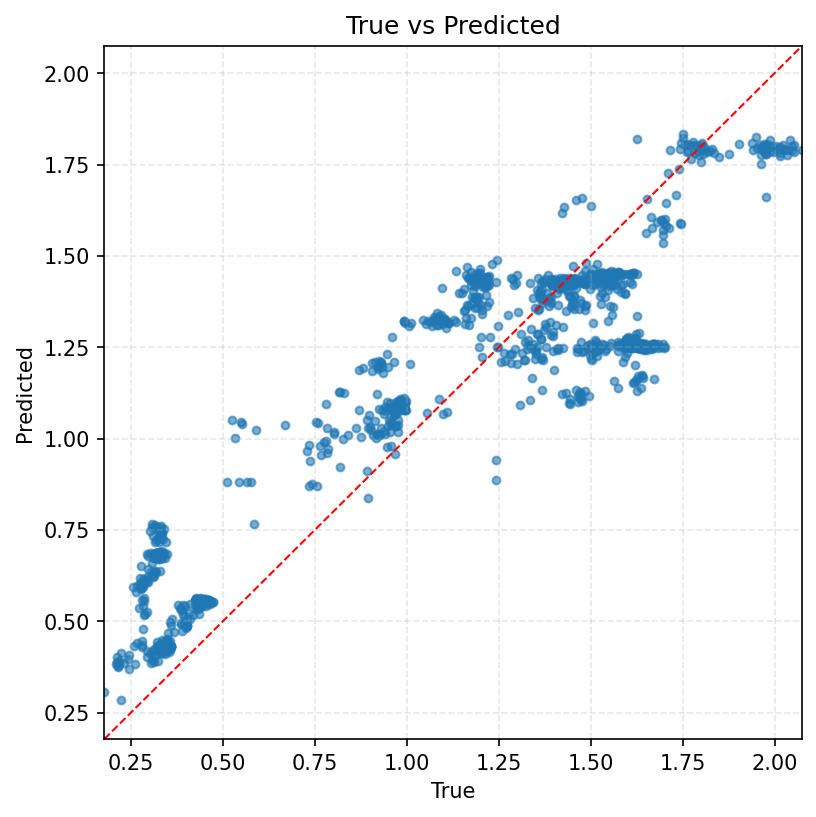

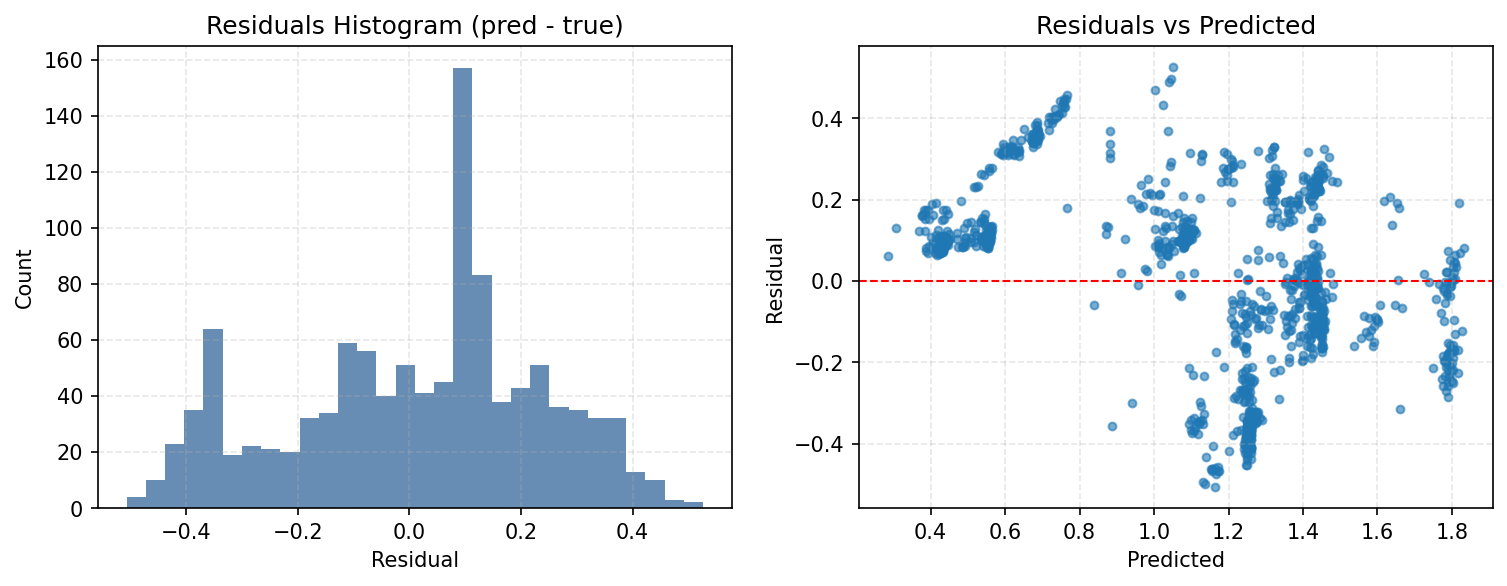

Saved plots to: /home/E2ETune-AI4DB/surrogate/true_vs_pred.png and /home/E2ETune-AI4DB/surrogate/residual_diagnostics.png


In [18]:
# Plot true vs predicted and residual diagnostics (static images, backend-agnostic)
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from IPython.display import Image, display

# Ensure inference variables exist
try:
    y_true
    y_pred
except NameError:
    raise RuntimeError('Please run the model inference cell first to compute y_true and y_pred.')

# Build a comparison DataFrame if not available
if 'comp_df' in globals() and isinstance(comp_df, pd.DataFrame):
    comp = comp_df.copy()
else:
    comp = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
    })
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        try:
            comp['bench'] = df.iloc[test_idx]['bench'].values if 'bench' in df.columns else None
            comp['workload_idx'] = df.iloc[test_idx]['workload_idx'].values if 'workload_idx' in df.columns else None
        except Exception:
            pass

# Output directory
try:
    out_dir = project_root / 'surrogate'
except Exception:
    out_dir = Path('surrogate')
out_dir.mkdir(parents=True, exist_ok=True)

# Ranges and residuals
minv = float(np.min([comp['y_true'].min(), comp['y_pred'].min()]))
maxv = float(np.max([comp['y_true'].max(), comp['y_pred'].max()]))
resid = comp['y_pred'].values - comp['y_true'].values

# Figure 1: True vs Predicted
fig1 = Figure(figsize=(6, 6))
_ = FigureCanvas(fig1)
ax1 = fig1.add_subplot(111)
ax1.scatter(comp['y_true'].values, comp['y_pred'].values, s=14, alpha=0.6)
ax1.plot([minv, maxv], [minv, maxv], 'r--', lw=1)
ax1.set_xlabel('True')
ax1.set_ylabel('Predicted')
ax1.set_title('True vs Predicted')
ax1.set_xlim(minv, maxv)
ax1.set_ylim(minv, maxv)
ax1.grid(True, ls='--', alpha=0.3)
true_vs_pred_path = out_dir / 'true_vs_pred.png'
fig1.savefig(true_vs_pred_path, dpi=150, bbox_inches='tight')
display(Image(filename=str(true_vs_pred_path)))

# Figure 2: Residual diagnostics (hist + residuals vs predicted)
fig2 = Figure(figsize=(12, 4))
_ = FigureCanvas(fig2)
axh = fig2.add_subplot(121)
axh.hist(resid, bins=30, color='#4e79a7', alpha=0.85)
axh.set_title('Residuals Histogram (pred - true)')
axh.set_xlabel('Residual')
axh.set_ylabel('Count')
axh.grid(True, ls='--', alpha=0.3)

axr = fig2.add_subplot(122)
axr.scatter(comp['y_pred'].values, resid, s=14, alpha=0.6)
axr.axhline(0.0, color='r', ls='--', lw=1)
axr.set_title('Residuals vs Predicted')
axr.set_xlabel('Predicted')
axr.set_ylabel('Residual')
axr.grid(True, ls='--', alpha=0.3)
resid_path = out_dir / 'residual_diagnostics.png'
fig2.savefig(resid_path, dpi=150, bbox_inches='tight')
display(Image(filename=str(resid_path)))

print(f"Saved plots to: {true_vs_pred_path} and {resid_path}")


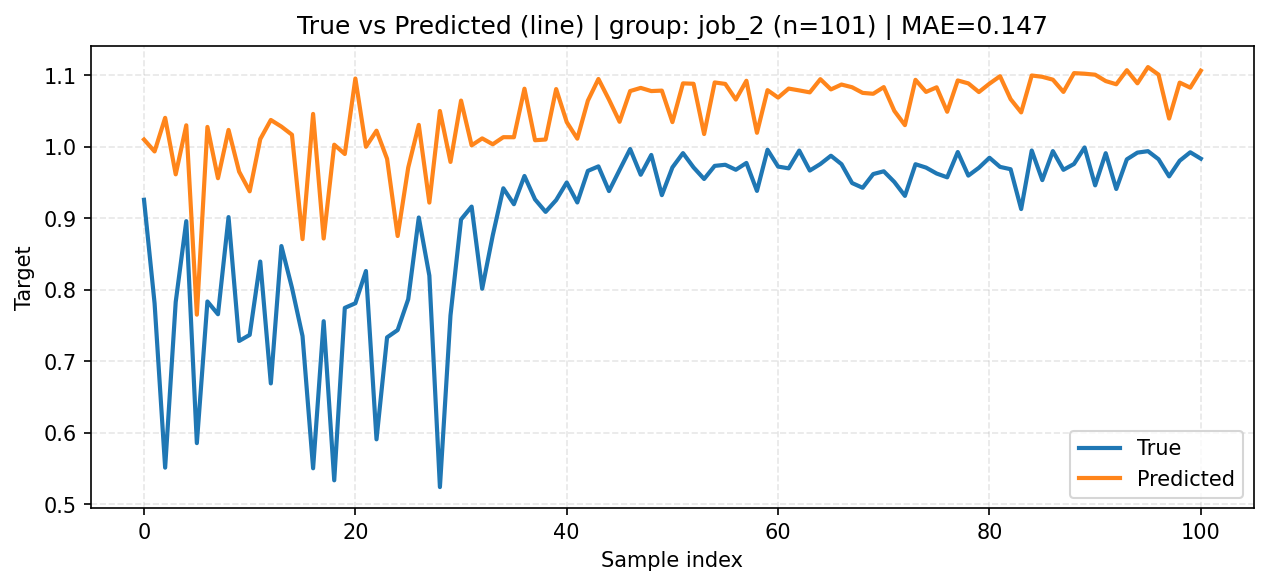

Saved line plot to: /home/E2ETune-AI4DB/surrogate/line_true_pred.png


In [19]:
# Line graph: True and Predicted over a subset (two colors)
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from IPython.display import Image, display
from sklearn.metrics import mean_absolute_error

# Ensure inference variables exist
try:
    y_true
    y_pred
except NameError:
    raise RuntimeError('Please run the model inference cell first to compute y_true and y_pred.')

# Build comparison DataFrame
if 'comp_df' in globals() and isinstance(comp_df, pd.DataFrame):
    comp = comp_df.copy()
else:
    comp = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        try:
            comp['bench'] = df.iloc[test_idx]['bench'].values if 'bench' in df.columns else None
            comp['workload_idx'] = df.iloc[test_idx]['workload_idx'].values if 'workload_idx' in df.columns else None
        except Exception:
            pass

# Choose subset strategy
n = 120  # maximum number of points to plot
subset_mode = 'group'  # options: 'group' | 'random' | 'first'

if subset_mode == 'group' and {'bench','workload_idx'}.issubset(comp.columns):
    # Pick the largest test group for a coherent time-like series
    group_sizes = comp.groupby(['bench','workload_idx']).size().sort_values(ascending=False)
    (b, w) = group_sizes.index[0]
    sub = comp[(comp['bench'] == b) & (comp['workload_idx'] == w)].copy()
    title_note = f"group: {b}_{w} (n={len(sub)})"
    # If still very large, take head n to keep it readable
    if len(sub) > n:
        sub = sub.head(n)
        title_note += f", clipped to {n}"
else:
    if subset_mode == 'random':
        sub = comp.sample(min(n, len(comp)), random_state=42).sort_index()
        title_note = f"random sample (n={len(sub)})"
    else:
        sub = comp.head(min(n, len(comp))).copy()
        title_note = f"first {len(sub)} samples"

sub = sub.reset_index(drop=True)
mae = float(mean_absolute_error(sub['y_true'], sub['y_pred']))

# Prepare output path
try:
    out_dir = project_root / 'surrogate'
except Exception:
    out_dir = Path('surrogate')
out_dir.mkdir(parents=True, exist_ok=True)
line_path = out_dir / 'line_true_pred.png'

# Plot as static image (backend-agnostic)
fig = Figure(figsize=(10, 4))
_ = FigureCanvas(fig)
ax = fig.add_subplot(111)
ax.plot(sub.index.values, sub['y_true'].values, label='True', color='#1f77b4', lw=2)
ax.plot(sub.index.values, sub['y_pred'].values, label='Predicted', color='#ff7f0e', lw=2, alpha=0.95)
ax.set_xlabel('Sample index')
ax.set_ylabel('Target')
ax.set_title(f'True vs Predicted (line) | {title_note} | MAE={mae:.3f}')
ax.grid(True, ls='--', alpha=0.3)
ax.legend(loc='best')
fig.savefig(line_path, dpi=150, bbox_inches='tight')
display(Image(filename=str(line_path)))

print(f"Saved line plot to: {line_path}")


In [ ]:
# Batch inference from folders: configs + metrics + plans (JSON)
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List

# Reuse vectorize_plans if present; otherwise define a minimal fallback
try:
    vectorize_plans
except NameError:
    import re
    OP_RE = re.compile(r'([A-Za-z ]+)\(cost=([0-9.]+)\)')
    def vectorize_plans(plan_strings: List[str]) -> Dict[str, float]:
        op_counts: Dict[str, int] = {}
        top_costs: List[float] = []
        depths: List[int] = []
        for s in plan_strings or []:
            ops = OP_RE.findall(s)
            if not ops:
                continue
            try:
                top_costs.append(float(ops[0][1]))
            except Exception:
                pass
            depths.append(s.count('('))
            for name, cost in ops:
                key = name.strip().lower().replace(' ', '_')
                op_counts[key] = op_counts.get(key, 0) + 1
        total_ops = sum(op_counts.values()) or 1
        ratios = {f'plan__ratio__{k}': (v / total_ops) for k, v in op_counts.items()}
        agg = {
            'plan__cost_mean': float(np.mean(top_costs)) if top_costs else 0.0,
            'plan__cost_std': float(np.std(top_costs)) if top_costs else 0.0,
            'plan__cost_min': float(np.min(top_costs)) if top_costs else 0.0,
            'plan__cost_max': float(np.max(top_costs)) if top_costs else 0.0,
            'plan__depth_mean': float(np.mean(depths)) if depths else 0.0,
            'plan__depth_max': float(np.max(depths)) if depths else 0.0,
            'plan__has_index_scan': int('index_scan' in op_counts),
            'plan__has_seq_scan': int('seq_scan' in op_counts),
            'plan__has_sort': int('sort' in op_counts),
            'plan__has_aggregate': int('aggregate' in op_counts),
            'plan__has_hash_join': int('hash_join' in op_counts),
            'plan__has_nested_loop': int('nested_loop' in op_counts),
            'plan__has_merge_join': int('merge_join' in op_counts),
            'plan__has_gather': int('gather' in op_counts),
            'plan__has_gather_merge': int('gather_merge' in op_counts),
            'plan__has_bitmap_scan': int('bitmap_heap_scan' in op_counts or 'bitmap_index_scan' in op_counts),
        }
        counts = {f'plan__count__{k}': v for k, v in op_counts.items()}
        return {**counts, **ratios, **agg}

# Load saved artifacts: model, feature list, scaler stats, knob ranges
try:
    base_dir = project_root
except NameError:
    base_dir = Path('.')
art_dir = (base_dir / 'surrogate')
model_path = art_dir / 'cost_model.pkl'
feat_list_path = art_dir / 'best_r2_features.txt'
scaler_path = art_dir / 'feature_scaler.json'
knob_cfg_path = base_dir / 'knob_config' / 'knob_config.json'

import joblib
mdl = joblib.load(model_path)

with open(feat_list_path, 'r') as f:
    expected_cols = [ln.strip() for ln in f if ln.strip()]

with open(scaler_path, 'r') as f:
    scaler_stats = json.load(f)

with open(knob_cfg_path, 'r') as f:
    knob_ranges = json.load(f)

def _normalize_knob(orig_key, val):
    rng = knob_ranges.get(orig_key)
    if rng is None:
        return float(val) if pd.notnull(val) else 0.0
    mn = float(rng.get('min', 0.0))
    mx = float(rng.get('max', mn))
    if not pd.notnull(val):
        return 0.0
    v = float(val)
    return 0.0 if mx == mn else (v - mn) / (mx - mn)

# Core feature builder for one triple of files
from pandas import json_normalize

def build_feature_row(config_json: Path, metrics_json: Path, plans_json: Path) -> Dict[str, float]:
    # Config
    with open(config_json, 'r') as f:
        cfg_raw = json.load(f)
    cfg_flat = json_normalize(cfg_raw, sep='__').to_dict(orient='records')[0] if isinstance(cfg_raw, dict) else {}
    cfg_feats = {f'cfg__{k}': v for k, v in cfg_flat.items()}
    # Metrics
    with open(metrics_json, 'r') as f:
        metrics_raw = json.load(f)
    metrics_flat_df = json_normalize(metrics_raw, sep='__')
    metrics_flat = metrics_flat_df.to_dict(orient='records')[0] if len(metrics_flat_df) else {}
    metrics_feats = {f'metrics__{k}': v for k, v in metrics_flat.items()}
    # Plans
    with open(plans_json, 'r') as f:
        plans_raw = json.load(f)
    plan_strings = plans_raw.get('query_plans', plans_raw.get('plans', []))
    plan_feats = vectorize_plans(plan_strings if isinstance(plan_strings, list) else [])
    # Merge
    row = {}
    row.update(cfg_feats)
    row.update(metrics_feats)
    row.update(plan_feats)  # keys already prefixed plan__*
    return row

# Apply all training-time transforms: knob normalization, dummies, min-max scaler, alignment

def prepare_features_for_inference(rows: List[Dict[str, float]]) -> pd.DataFrame:
    X_inf = pd.DataFrame(rows)
    # Knob normalization
    cfg_cols = [c for c in X_inf.columns if c.startswith('cfg__')]
    for c in cfg_cols:
        orig = c.replace('cfg__', '')
        X_inf[c] = pd.to_numeric(X_inf[c], errors='coerce')
        X_inf[c] = X_inf[c].apply(lambda v: _normalize_knob(orig, v))
    # Dummies for categoricals
    cat_cols = [c for c in X_inf.columns if X_inf[c].dtype == 'object']
    X_inf = pd.get_dummies(X_inf, columns=cat_cols, dummy_na=True)
    # Ensure numeric
    for col in X_inf.columns:
        if X_inf[col].dtype == bool:
            X_inf[col] = X_inf[col].astype(int)
        if not np.issubdtype(X_inf[col].dtype, np.number):
            X_inf[col] = pd.to_numeric(X_inf[col], errors='coerce').fillna(0)
    # Train-only min-max normalization for the recorded columns
    norm_cols: List[str] = scaler_stats.get('normalized_columns', [])
    feature_min = scaler_stats.get('feature_min', {})
    feature_range = scaler_stats.get('feature_range', {})
    for c in norm_cols:
        if c in X_inf.columns:
            mn = float(feature_min.get(c, 0.0))
            rg = float(feature_range.get(c, 0.0))
            if rg == 0.0:
                X_inf[c] = 0.0
            else:
                X_inf[c] = (pd.to_numeric(X_inf[c], errors='coerce') - mn) / rg
            X_inf[c] = X_inf[c].fillna(0.0).clip(0.0, 1.0)
    # Column alignment
    for c in expected_cols:
        if c not in X_inf.columns:
            X_inf[c] = 0.0
    extra_cols = [c for c in X_inf.columns if c not in expected_cols]
    if extra_cols:
        X_inf = X_inf.drop(columns=extra_cols)
    X_inf = X_inf[expected_cols]
    return X_inf

# Batch driver: match files by stem across three folders (intersection of basenames)

def run_batch_inference(config_dir: Path, metrics_dir: Path, plans_dir: Path, out_csv: Path) -> pd.DataFrame:
    config_dir = Path(config_dir)
    metrics_dir = Path(metrics_dir)
    plans_dir = Path(plans_dir)
    cfg_map = {p.stem: p for p in config_dir.glob('*.json')}
    met_map = {p.stem: p for p in metrics_dir.glob('*.json')}
    pln_map = {p.stem: p for p in plans_dir.glob('*.json')}
    keys = sorted(set(cfg_map) & set(met_map) & set(pln_map))
    if not keys:
        raise FileNotFoundError('No common file stems found across the three folders.')
    rows = []
    id_list = []
    for k in keys:
        try:
            row = build_feature_row(cfg_map[k], met_map[k], pln_map[k])
            rows.append(row)
            id_list.append(k)
        except Exception as e:
            print(f'Skipped {k}:', e)
    X_inf = prepare_features_for_inference(rows)
    y_pred = mdl.predict(X_inf.values)
    out = pd.DataFrame({'id': id_list, 'y_pred': y_pred})
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(out_csv, index=False)
    print(f'Wrote predictions for {len(out)} items to {out_csv}')
    return out

# Example usage (edit these paths to your folders):
cfg_dir = base_dir / 'inference_configs'
met_dir = base_dir / 'inference_internal_metrics'
pln_dir = base_dir / 'inference_query_plans'
out_path = art_dir / 'inference_predictions.csv'
preds_df = run_batch_inference(cfg_dir, met_dir, pln_dir, out_path)


# Single-JSON Inference: Expected Schema and Output
- Use a single JSON file that contains all inputs:
  - `config`: a dict of knob settings (nested ok).
  - `metrics` (or `internal_metrics`): a dict of workload/internal metrics (nested ok).
  - `query_plans` (preferred) or `plans`: a list of textual plan strings.
- The code flattens `config` and `metrics`, vectorizes `query_plans`, applies the same normalization used in training, aligns columns, and predicts.
- Artifacts loaded:
  - Model: `surrogate/cost_model.pkl`
  - Feature list: `surrogate/best_r2_features.txt`
  - Train-time scaler stats: `surrogate/feature_scaler.json`
  - Knob ranges: `knob_config/knob_config.json`
- Output: returns a DataFrame with `id` (optional) and `y_pred` (training-target scale).

In [33]:
# Infer from a single combined JSON (config + metrics + plans)
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Union
from pandas import json_normalize

# Reuse artifacts and helpers if already loaded; else load here
try:
    base_dir
except NameError:
    base_dir = Path('.')
art_dir = base_dir / 'surrogate'
model_path = art_dir / 'cost_model.pkl'
feat_list_path = art_dir / 'best_r2_features.txt'
scaler_path = art_dir / 'feature_scaler.json'
knob_cfg_path = base_dir / 'knob_config' / 'knob_config.json'

try:
    vectorize_plans
except NameError:
    import re
    OP_RE = re.compile(r'([A-Za-z ]+)\(cost=([0-9.]+)\)')
    def vectorize_plans(plan_strings: List[Union[str, dict]]) -> Dict[str, float]:
        op_counts: Dict[str, int] = {}
        top_costs: List[float] = []
        depths: List[int] = []
        for s in plan_strings or []:
            s = str(s)
            ops = OP_RE.findall(s)
            if not ops:
                continue
            try:
                top_costs.append(float(ops[0][1]))
            except Exception:
                pass
            depths.append(s.count('('))
            for name, cost in ops:
                key = name.strip().lower().replace(' ', '_')
                op_counts[key] = op_counts.get(key, 0) + 1
        total_ops = sum(op_counts.values()) or 1
        ratios = {f'plan__ratio__{k}': (v / total_ops) for k, v in op_counts.items()}
        agg = {
            'plan__cost_mean': float(np.mean(top_costs)) if top_costs else 0.0,
            'plan__cost_std': float(np.std(top_costs)) if top_costs else 0.0,
            'plan__cost_min': float(np.min(top_costs)) if top_costs else 0.0,
            'plan__cost_max': float(np.max(top_costs)) if top_costs else 0.0,
            'plan__depth_mean': float(np.mean(depths)) if depths else 0.0,
            'plan__depth_max': float(np.max(depths)) if depths else 0.0,
            'plan__has_index_scan': int('index_scan' in op_counts),
            'plan__has_seq_scan': int('seq_scan' in op_counts),
            'plan__has_sort': int('sort' in op_counts),
            'plan__has_aggregate': int('aggregate' in op_counts),
            'plan__has_hash_join': int('hash_join' in op_counts),
            'plan__has_nested_loop': int('nested_loop' in op_counts),
            'plan__has_merge_join': int('merge_join' in op_counts),
            'plan__has_gather': int('gather' in op_counts),
            'plan__has_gather_merge': int('gather_merge' in op_counts),
            'plan__has_bitmap_scan': int('bitmap_heap_scan' in op_counts or 'bitmap_index_scan' in op_counts),
        }
        counts = {f'plan__count__{k}': v for k, v in op_counts.items()}
        return {**counts, **ratios, **agg}

import joblib
mdl = joblib.load(model_path)
with open(feat_list_path, 'r') as f:
    expected_cols = [ln.strip() for ln in f if ln.strip()]
with open(scaler_path, 'r') as f:
    scaler_stats = json.load(f)
with open(knob_cfg_path, 'r') as f:
    knob_ranges = json.load(f)

def _normalize_knob(orig_key, val):
    rng = knob_ranges.get(orig_key)
    if rng is None:
        return float(val) if pd.notnull(val) else 0.0
    mn = float(rng.get('min', 0.0))
    mx = float(rng.get('max', mn))
    if not pd.notnull(val):
        return 0.0
    v = float(val)
    return 0.0 if mx == mn else (v - mn) / (mx - mn)

def _flatten_first_record(obj: Union[dict, list]) -> Dict:
    """Safely flatten a dict or list of dicts into a single record dict."""
    if isinstance(obj, dict):
        if not obj:
            return {}
        df = json_normalize(obj, sep='__')
        if isinstance(df, pd.DataFrame) and df.shape[0] >= 1:
            recs = df.to_dict(orient='records')
            return recs[0] if recs else {}
        return {}
    if isinstance(obj, list):
        if not obj:
            return {}
        df = json_normalize(obj, sep='__')
        if isinstance(df, pd.DataFrame) and df.shape[0] >= 1:
            recs = df.to_dict(orient='records')
            return recs[0] if recs else {}
        return {}
    return {}

# Build features from a single combined JSON

def build_row_from_combined_json(data: Dict) -> Dict[str, float]:
    cfg_raw = data.get('config', {})
    metrics_raw = data.get('metrics', data.get('internal_metrics', {}))
    plans_list = data.get('query_plans', data.get('plans', []))
    # Config
    cfg_flat = _flatten_first_record(cfg_raw)
    cfg_feats = {f'cfg__{k}': v for k, v in cfg_flat.items()}
    # Metrics
    metrics_flat = _flatten_first_record(metrics_raw)
    metrics_feats = {f'metrics__{k}': v for k, v in metrics_flat.items()}
    # Plans
    plan_feats = vectorize_plans(plans_list if isinstance(plans_list, list) else [])
    # Merge
    row: Dict[str, float] = {}
    row.update(cfg_feats)
    row.update(metrics_feats)
    row.update(plan_feats)
    # Optional identifiers
    if isinstance(data.get('id', None), (str, int)):
        row['id'] = data['id']
    return row

# Prepare features and predict for a single JSON file

def infer_from_single_json(json_path: Path, out_path: Path = None) -> pd.DataFrame:
    json_path = Path(json_path)
    with open(json_path, 'r') as f:
        data = json.load(f)
    row = build_row_from_combined_json(data)
    X_inf = pd.DataFrame([row])
    # Knob normalization
    cfg_cols = [c for c in X_inf.columns if c.startswith('cfg__')]
    for c in cfg_cols:
        orig = c.replace('cfg__', '')
        X_inf[c] = pd.to_numeric(X_inf[c], errors='coerce')
        X_inf[c] = X_inf[c].apply(lambda v: _normalize_knob(orig, v))
    # Dummies for categoricals
    cat_cols = [c for c in X_inf.columns if X_inf[c].dtype == 'object']
    X_inf = pd.get_dummies(X_inf, columns=cat_cols, dummy_na=True)
    # Ensure numeric
    for col in X_inf.columns:
        if X_inf[col].dtype == bool:
            X_inf[col] = X_inf[col].astype(int)
        if not np.issubdtype(X_inf[col].dtype, np.number):
            X_inf[col] = pd.to_numeric(X_inf[col], errors='coerce').fillna(0)
    # Train-time min–max normalization
    norm_cols: List[str] = scaler_stats.get('normalized_columns', [])
    feature_min = scaler_stats.get('feature_min', {})
    feature_range = scaler_stats.get('feature_range', {})
    for c in norm_cols:
        if c in X_inf.columns:
            mn = float(feature_min.get(c, 0.0))
            rg = float(feature_range.get(c, 0.0))
            if rg == 0.0:
                X_inf[c] = 0.0
            else:
                X_inf[c] = (pd.to_numeric(X_inf[c], errors='coerce') - mn) / rg
            X_inf[c] = X_inf[c].fillna(0.0).clip(0.0, 1.0)
    # Column alignment
    for c in expected_cols:
        if c not in X_inf.columns:
            X_inf[c] = 0.0
    extra_cols = [c for c in X_inf.columns if c not in expected_cols]
    if extra_cols:
        X_inf = X_inf.drop(columns=extra_cols)
    X_inf = X_inf[expected_cols]
    # Predict (model trained on y_log)
    y_pred_log = mdl.predict(X_inf.values)
    # Convert to raw scale
    y_pred_raw = np.expm1(y_pred_log)
    out = pd.DataFrame({'y_pred_log': y_pred_log, 'y_pred_raw': y_pred_raw})
    if 'id' in row:
        out.insert(0, 'id', row['id'])
    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out.to_csv(out_path, index=False)
        print(f'Wrote single-file prediction to {out_path}')
    return out

# Example usage (edit the file path, then run):
single_json = art_dir / 'inference_configs' / 'job.json'
out_csv = art_dir / 'prediction_single_job.csv'
result_df = infer_from_single_json(single_json, out_csv)
try:
    display(result_df)
except Exception:
    print(result_df)


Wrote single-file prediction to /home/E2ETune-AI4DB/surrogate/prediction_single_job.csv


,y_pred_log,y_pred_raw
0,3.020996,19.511705


In [ ]:
from pathlib import Path
from huggingface_hub import login, HfApi
import os

REPO_NAME = "NisithDissanayake/genknob-tuner"
# Load HF token from environment variable for security
HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN environment variable not set. Set it with: export HF_TOKEN='your_token_here'")

login(token=HF_TOKEN)

print(f"Pushing model to {REPO_NAME}...")

api = HfApi()
api.upload_file(
    path_or_fileobj=str(Path('surrogate') / 'cost_model.pkl'),
    path_in_repo="cost_model.pkl",                  
    repo_id=REPO_NAME,
    repo_type="model"
)

print("Success! Model and Artifacts are live on Hugging Face.")

/home/E2ETune-AI4DB/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pushing model to NisithDissanayake/genknob-tuner...


ValueError: Provided path: 'surrogate/cost_model.pkl' is not a file on the local file system